In [1]:
#importing the necessary modules
from keras.datasets import mnist
import numpy as np

2026-04-07 07:24:42.637788: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775546682.860360      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775546682.926052      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775546683.455431      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775546683.455476      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775546683.455479      17 computation_placer.cc:177] computation placer alr

In [2]:
#loading data
(xtrain,ytrain),(xtest,ytest)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Training data:


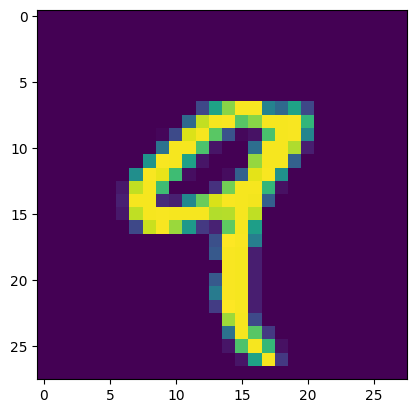

Label of this image is 9


In [3]:
#What mnist images look like
import matplotlib.pyplot as plt
print("Training data:")
plt.imshow(xtrain[4])
plt.show()
print("Label of this image is",ytrain[4])

In [4]:
#reshaping data as needed by the model
xtrain=np.reshape(xtrain,(-1,28,28,1))
xtest=np.reshape(xtest,(-1,28,28,1))
xtrain.shape,xtest.shape,ytrain.shape,ytest.shape

((60000, 28, 28, 1), (10000, 28, 28, 1), (60000,), (10000,))

In [5]:
#normalising
xtrain=xtrain/255
xtest=xtest/255

In [6]:
xtrain[1]

array([[[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        

In [7]:
#implementing one hot encoding
from keras.utils import to_categorical
y_train = to_categorical(ytrain, num_classes=10)
y_test = to_categorical(ytest, num_classes=10)

In [8]:
ytrain

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [9]:
y_train.shape

(60000, 10)

In [10]:
#importing the model
from keras.models import Sequential

In [11]:
#creating model object
model=Sequential()

In [12]:
#importing layers
from keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout

In [13]:
#adding layers and forming the model
model.add(Conv2D(32,kernel_size=5,strides=1,padding="Same",activation="relu",input_shape=(28,28,1)))
model.add(MaxPooling2D(padding="same"))

model.add(Conv2D(64,kernel_size=5,strides=1,padding="same",activation="relu"))
model.add(MaxPooling2D(padding="same"))

model.add(Conv2D(128,kernel_size=5,strides=1,padding="same",activation="relu"))
model.add(MaxPooling2D(padding="same"))


model.add(Flatten())

model.add(Dense(1024,activation="relu"))
#model.add(Dropout(0.2))
model.add(Dense(10,activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-07 07:25:10.332461: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,365,450 (9.02 MB)

 Trainable params: 2,365,450 (9.02 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
#compiling
model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

In [16]:
#training the model
model.fit(xtrain,y_train,batch_size=100,epochs=5,validation_data=(xtest,y_test))

Epoch 1/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 141s 232ms/step - accuracy: 0.8879 - loss: 0.3506 - val_accuracy: 0.9888 - val_loss: 0.0357
Epoch 2/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 138s 230ms/step - accuracy: 0.9893 - loss: 0.0354 - val_accuracy: 0.9878 - val_loss: 0.0380
Epoch 3/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 140s 233ms/step - accuracy: 0.9928 - loss: 0.0231 - val_accuracy: 0.9922 - val_loss: 0.0253
Epoch 4/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 141s 235ms/step - accuracy: 0.9941 - loss: 0.0175 - val_accuracy: 0.9927 - val_loss: 0.0221
Epoch 5/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 141s 236ms/step - accuracy: 0.9956 - loss: 0.0146 - val_accuracy: 0.9920 - val_loss: 0.0260


In [17]:
from sklearn.metrics import accuracy_score
import numpy as np

# Get predictions from the model (these are probabilities)
y_pred = model.predict(xtest)

# Convert probabilities to class labels (e.g., the index with the highest probability)
y_pred_labels = np.argmax(y_pred, axis=1)

# Convert one-hot encoded y_test to true class labels
y_true_labels = np.argmax(y_test, axis=1)

# Now calculate accuracy using the consistent class labels
accuracy = accuracy_score(y_true_labels, y_pred_labels)
print(f"Test Accuracy: {accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step
Test Accuracy: 0.992


In [18]:
#model train and test scores
model.evaluate(xtrain,y_train)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - accuracy: 0.9970 - loss: 0.0095


[0.009642424061894417, 0.9968833327293396]

In [19]:
model.evaluate(xtest,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9903 - loss: 0.0327


[0.025998687371611595, 0.9919999837875366]